# Does data augmentation move the memorization → generalization transition?

**Setup.** Unconditional UNet-128 trained on N HI maps (N counts 2-D slices; 16 slices per simulation, so N = 64 is 4 simulations).
Four ways of training, same data, same 200k updates, one training seed each:

| arm | what changes |
|---|---|
| **no augmentation** | the original model (N = 64 … 32,768) |
| **D4 + shift** | each training map is randomly rotated/flipped (8 options) and periodically shifted every time it is used |
| **D4-equivariant UNet** | the network is built to treat rotated/flipped maps identically; no augmentation |
| **smooth warp** | maps are smoothly distorted; a *control* that adds novelty by damaging the maps |

**Scores** come from `scripts/evaluate_run.py` (job 63428813, all regression checks passed), saved in
`results/unet128_aug_sweep/evaluate_run_v1/`. This notebook only reads those files and the saved samples.

**Prediction on record** (before sampling): the transition moves down by at most ×8 and N = 64 stays memorized. **It was wrong** (ledger verdict: unsupported).

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts/evaluate_run.py').is_file())
sys.path.insert(0, str(PROJECT_DIR))
RES = PROJECT_DIR / 'results/unet128_aug_sweep/evaluate_run_v1'
metrics = json.loads((RES / 'metrics.json').read_text())
assert metrics['trusted'], metrics['note']
table = pd.read_csv(RES / 'per_run.csv')
table = table[table.status == 'ok'].copy()
curves = np.load(RES / 'curves.npz')

plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['STIXGeneral', 'DejaVu Serif'], 'mathtext.fontset': 'stix',
    'font.size': 14, 'axes.titlesize': 15, 'axes.labelsize': 15, 'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 12.5, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 0.9,
    'lines.linewidth': 2.4, 'lines.markersize': 8, 'figure.dpi': 110})
ARMS = ['noaug', 'd4shift', 'd4equiv', 'warp']
NAME = {'noaug': 'No augmentation', 'd4shift': 'D4 + shift augmentation', 'd4equiv': 'D4-equivariant UNet',
        'warp': 'Smooth warp (control)'}
STYLE = {'noaug': dict(color='#333333', marker='o'), 'd4shift': dict(color='#2a78d6', marker='s'),
         'd4equiv': dict(color='#1baf7a', marker='D'), 'warp': dict(color='#eb6834', marker='^', ls='--')}
REF = dict(color='0.45', ls=':', marker='x', lw=1.8, label='real maps: training vs held-out')

def log2_axis(ax, sizes):
    ax.set_xscale('log', base=2)
    ax.set_xticks(sizes)
    ax.set_xticklabels([f'$2^{{{int(np.log2(n))}}}$' for n in sizes])
    ax.set_xlabel('Training set size $N$')
    ax.grid(alpha=0.18)

def arm_rows(arm):
    return table[table.arm == arm].sort_values('dataset_size')
print('source:', RES, '| trusted:', metrics['trusted'])

source: /home/jiamingp/diffusion_models_repo/results/unet128_aug_sweep/evaluate_run_v1 | trusted: True


## 1. The transition

**Generalization score G** (as in Fig. 1 of the paper): the fraction of generated maps that are *not* near-copies of a training map.
A map is a near-copy if its similarity to the closest training map exceeds the 95th percentile of training-to-training similarities.
Here the search also allows every rotation/flip of the generated map, so a rotated copy still counts as a copy.

* **G ≈ 0:** the model reproduces training maps (memorization).
* **G ≈ 1:** generated maps are as different from the training set as new maps are (generalization).

Middle: a stricter copy test in pixel space that also allows every periodic shift (computed for N ≤ 4096).

Right: G saturates at 1, so it cannot rank arms that all pass. This panel shows the *median* similarity of a generated map to its
closest training map (same rotation/flip/shift search). The gray line is the same number for held-out real maps: a model whose maps sit on it
produces maps that are exactly as new as real unseen simulations.

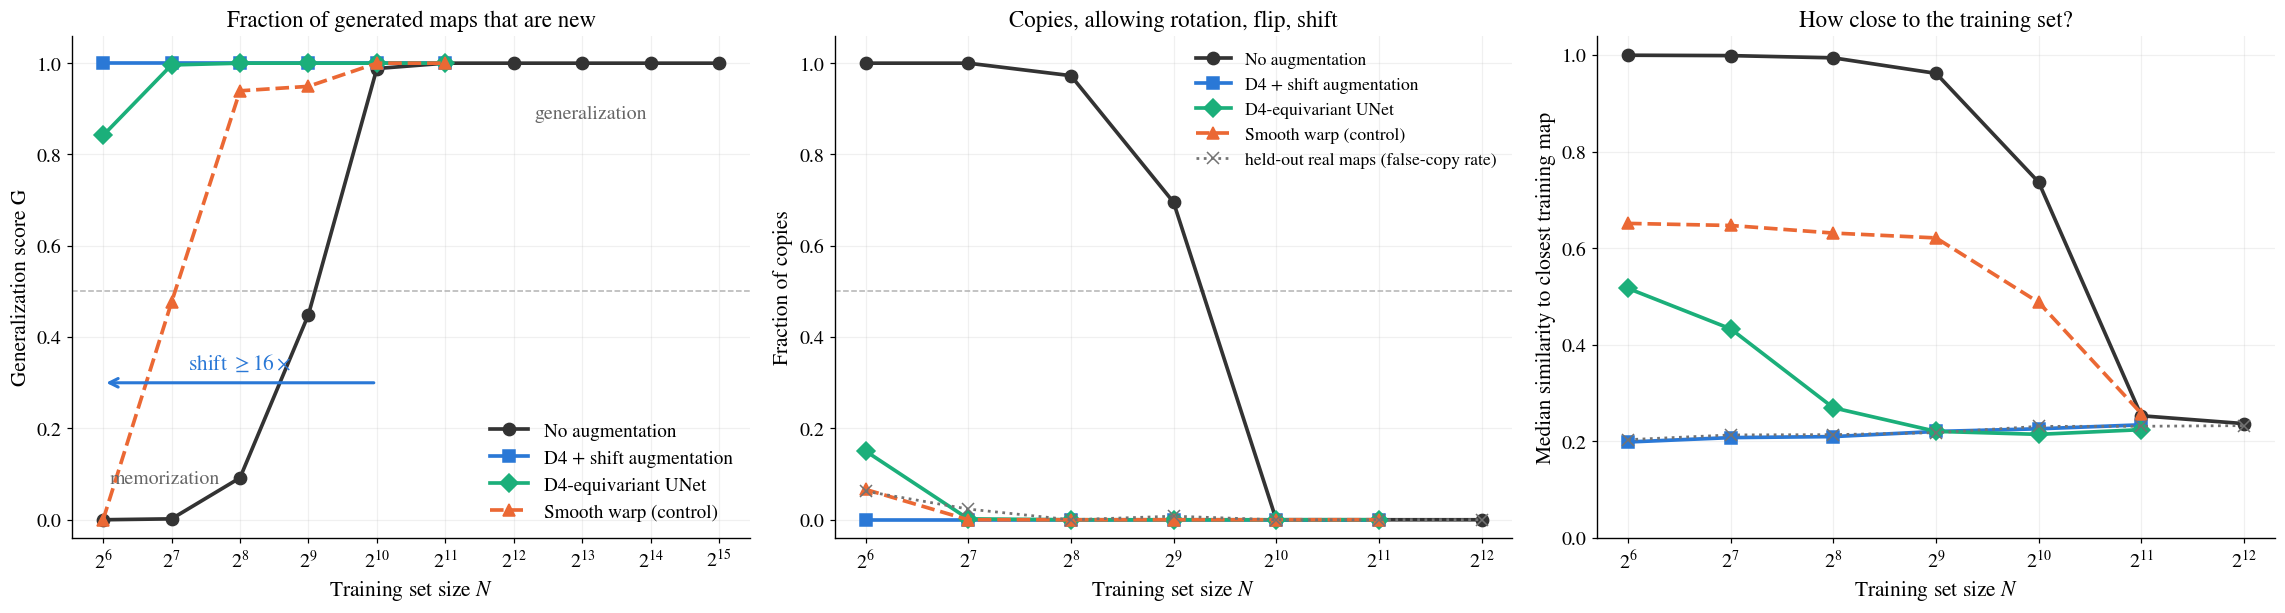

**Transition N (smallest N that is not memorized):** No augmentation: 1024, D4 + shift augmentation: ≤ 64 (already new at the smallest N trained), D4-equivariant UNet: ≤ 64 (already new at the smallest N trained), Smooth warp (control): 256

In [2]:
sizes = sorted(table.dataset_size.unique())
small = [n for n in sizes if n <= 4096]
fig, axes = plt.subplots(1, 3, figsize=(21, 5.8))
heldout_med = {}
for arm in ARMS:
    r = arm_rows(arm)
    axes[0].plot(r.dataset_size, r.G_d4, label=NAME[arm], **STYLE[arm])
    r2 = r[r.dataset_size <= 4096]
    axes[1].plot(r2.dataset_size, r2.orbit_copy_fraction, label=NAME[arm], **STYLE[arm])
    axes[2].plot(r2.dataset_size, r2.orbit_nn_median, label=NAME[arm], **STYLE[arm])
    if arm == 'noaug':
        for _, row in r2.iterrows():
            heldout_med[row.dataset_size] = float(np.median(np.load(RES / f'{row.run_name}_per_sample.npz')['heldout_orbit_nn']))
ref = table.drop_duplicates('dataset_size').sort_values('dataset_size')
ref = ref[ref.dataset_size <= 4096]
axes[1].plot(ref.dataset_size, ref.heldout_orbit_copy_fraction, **{**REF, 'label': 'held-out real maps (false-copy rate)'})
axes[2].plot(list(heldout_med), list(heldout_med.values()), **{**REF, 'label': 'held-out real maps'})
axes[0].set(ylabel='Generalization score G', ylim=(-0.04, 1.06), title='Fraction of generated maps that are new')
axes[1].set(ylabel='Fraction of copies', ylim=(-0.04, 1.06), title='Copies, allowing rotation, flip, shift')
axes[2].set(ylabel='Median similarity to closest training map', ylim=(0, 1.04), title='How close to the training set?')
for ax in axes[:2]:
    ax.axhline(0.5, color='0.7', lw=1, ls='--', zorder=0)
log2_axis(axes[0], sizes); log2_axis(axes[1], small); log2_axis(axes[2], small)
axes[0].text(2**6.1, 0.08, 'memorization', fontsize=13, color='0.4')
axes[0].text(2**12.3, 0.88, 'generalization', fontsize=13, color='0.4')
noaug_T = next(t['N_T'] for t in metrics['transition'] if t['arm'] == 'noaug')
axes[0].annotate('', xy=(2**6, 0.3), xytext=(noaug_T, 0.3), arrowprops=dict(arrowstyle='->', color='#2a78d6', lw=2))
axes[0].text(2**8, 0.33, r'shift $\geq 16\times$', color='#2a78d6', fontsize=14, ha='center')
axes[0].legend(loc='lower right', frameon=False)
axes[1].legend(loc='upper right', frameon=False, fontsize=11.5)
plt.tight_layout(); plt.show()
display(Markdown('**Transition N (smallest N that is not memorized):** ' + ', '.join(
    f"{NAME[t['arm']]}: {t['N_T'] if t['arm'] in ('noaug', 'warp') else '≤ 64 (already new at the smallest N trained)'}"
    for t in sorted(metrics['transition'], key=lambda t: ARMS.index(t['arm'])))))

**How to read it.**

* **No augmentation (black):** copies until N = 2⁹ (G = 0.45, 70% exact copies) and is new from N = 2¹⁰ (G = 0.99).
* **D4 + shift (blue):** G = 1.00 and zero copies already at N = 2⁶, the smallest N trained. Its maps are as far from the training set as held-out
  real maps are (right panel: median similarity 0.20 vs 0.20 for real maps).
* **D4-equivariant UNet (green):** G = 0.84 at N = 2⁶, with 15% copies that are rotated or flipped training maps (held-out real maps: 6%).
  Below the copy threshold, but not copy-free.
* **Smooth warp (orange):** passes the novelty test from N = 2⁸ (G = 0.94), but section 2 shows that is damage, not generalization.

**So how far did the transition move?** On this 2× grid, the first non-copying N fell from 2¹⁰ to ≤ 2⁶ (a factor of at least 16 on the grid).
Since the no-augmentation model crosses G = 0.5 between 2⁹ (G = 0.45) and 2¹⁰, the safe statement is **more than a factor 8**.
Where the D4 + shift transition actually is, this grid cannot tell: it lies below N = 64.

## 2. Are the new maps *good*, or just different?

Novelty alone is cheap: a model that outputs noise has G = 1. Each panel compares generated maps with held-out real maps.
The **gray dotted line** is the same comparison for real training maps vs real held-out maps, i.e. what a perfect model would score.

* **P(k) ratio:** power spectrum of generated maps / held-out real maps, averaged over large, mid and small scales (1 = perfect).
* **One-point L1:** difference between the pixel-value histograms (0 = perfect).
* **Probe Ωm distance:** how far the distribution of Ωm values read from the maps (by the frozen VGG regressor) is from that of the training maps (0 = perfect).

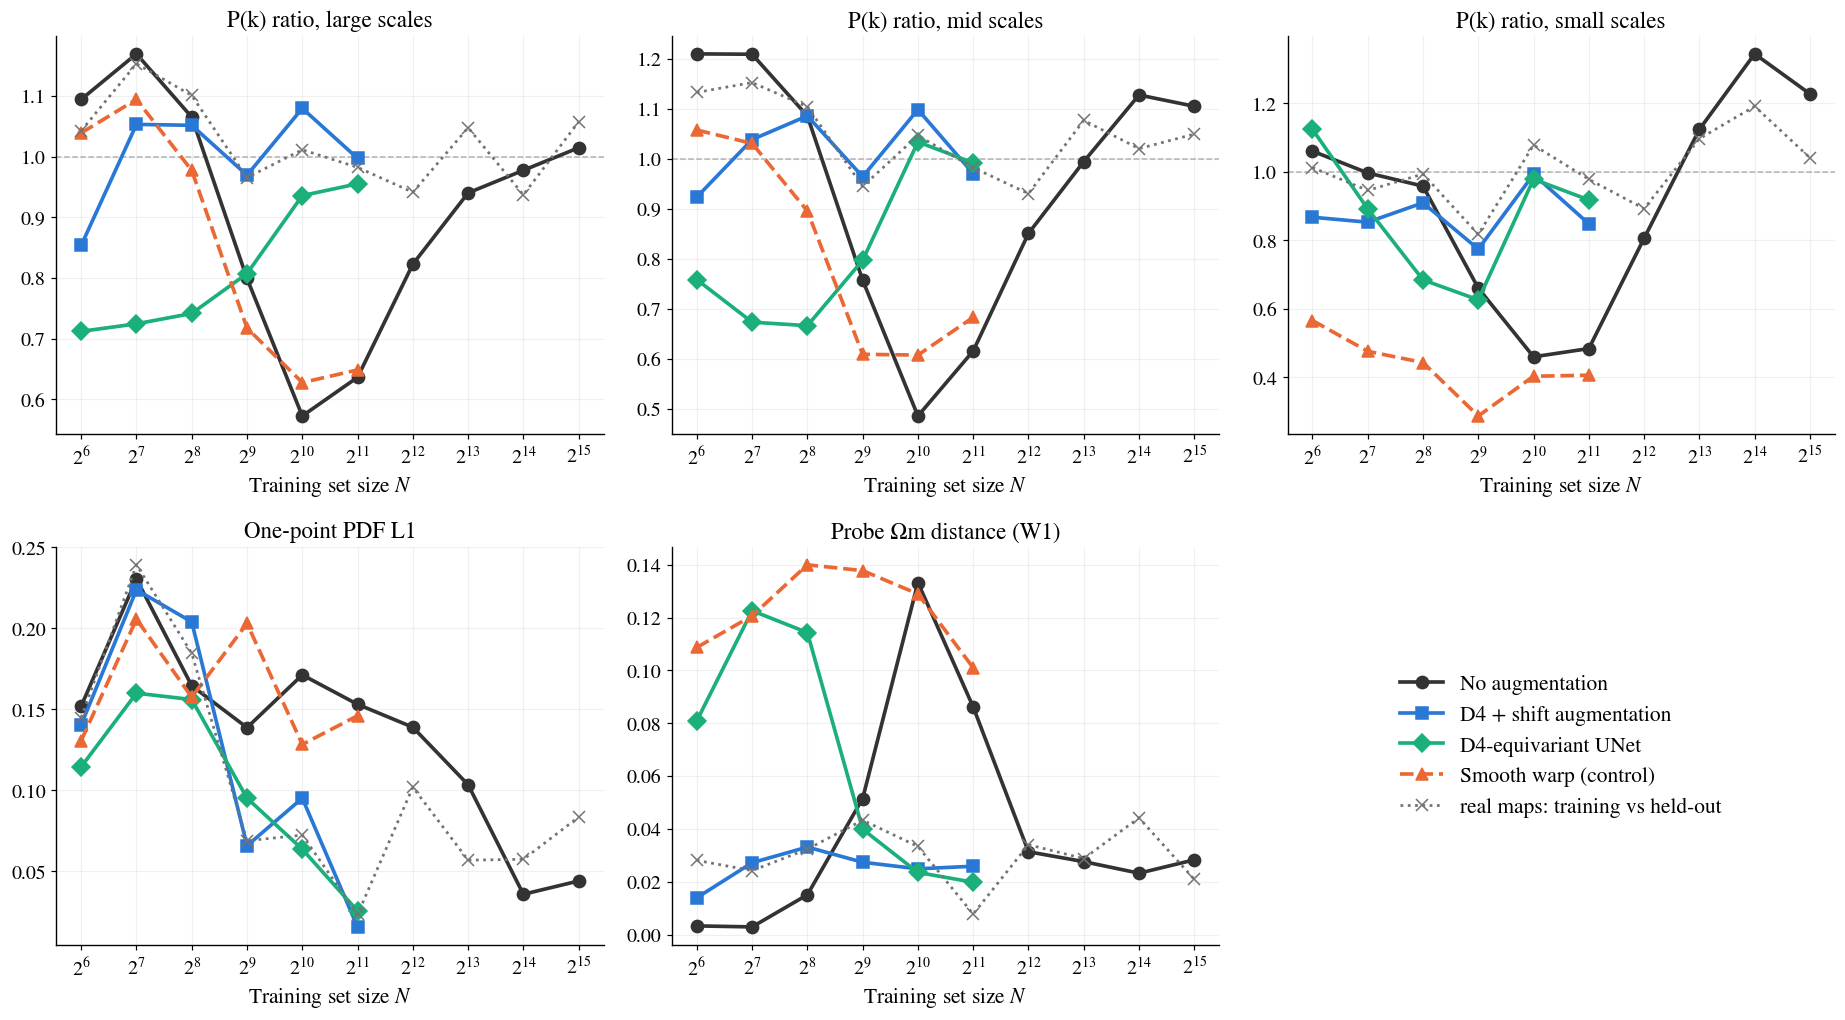

In [3]:
panels = [('pk_large', 'ref_pk_large', 'P(k) ratio, large scales'), ('pk_mid', 'ref_pk_mid', 'P(k) ratio, mid scales'),
          ('pk_small', 'ref_pk_small', 'P(k) ratio, small scales'), ('one_point_l1', 'ref_one_point_l1', 'One-point PDF L1'),
          ('probe_Omega_m_W1_gen_vs_train', 'ref_probe_Omega_m_W1_heldout_vs_train', 'Probe Ωm distance (W1)')]
fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))
for ax, (col, rcol, title) in zip(axes.ravel(), panels):
    for arm in ARMS:
        r = arm_rows(arm)
        ax.plot(r.dataset_size, r[col], label=NAME[arm], **STYLE[arm])
    ax.plot(ref.dataset_size if False else table.drop_duplicates('dataset_size').sort_values('dataset_size').dataset_size,
            table.drop_duplicates('dataset_size').sort_values('dataset_size')[rcol], **REF)
    if col.startswith('pk_'):
        ax.axhline(1, color='0.7', lw=1, ls='--', zorder=0)
    ax.set_title(title); log2_axis(ax, sizes)
axes[1, 2].axis('off')
h, l = axes[0, 0].get_legend_handles_labels()
axes[1, 2].legend(h, l, loc='center', frameon=False, fontsize=14)
plt.tight_layout(); plt.show()

**How to read it.**

* **D4 + shift (blue):** large- and mid-scale P(k), one-point L1 and probe distance stay within the real-map reference at every N.
  Small-scale power is 9–23% low at 5 of 6 N.
* **D4-equivariant UNet (green):** short of power up to N = 2⁹ (large 0.71–0.81, mid 0.67–0.80), at all scales from 2⁸, and far from the
  training set in probe space for N ≤ 2⁸ (0.08–0.12 vs ≤ 0.03 for real maps). Its samples also look speckled (section 5).
* **Smooth warp (orange):** small-scale P(k) 0.29–0.57: the novelty is damage.
* **No augmentation (black):** poorest right at its own transition (N = 2¹⁰–2¹¹: P(k) 0.46–0.64, probe distance 0.13/0.09). P(k) and probe
  recover by 2¹³; the one-point PDF matches the reference only from 2¹⁴.

## 3. Power spectrum ratio per training-set size

Generated / held-out real P(k) for each arm; gray dotted: real training / held-out.

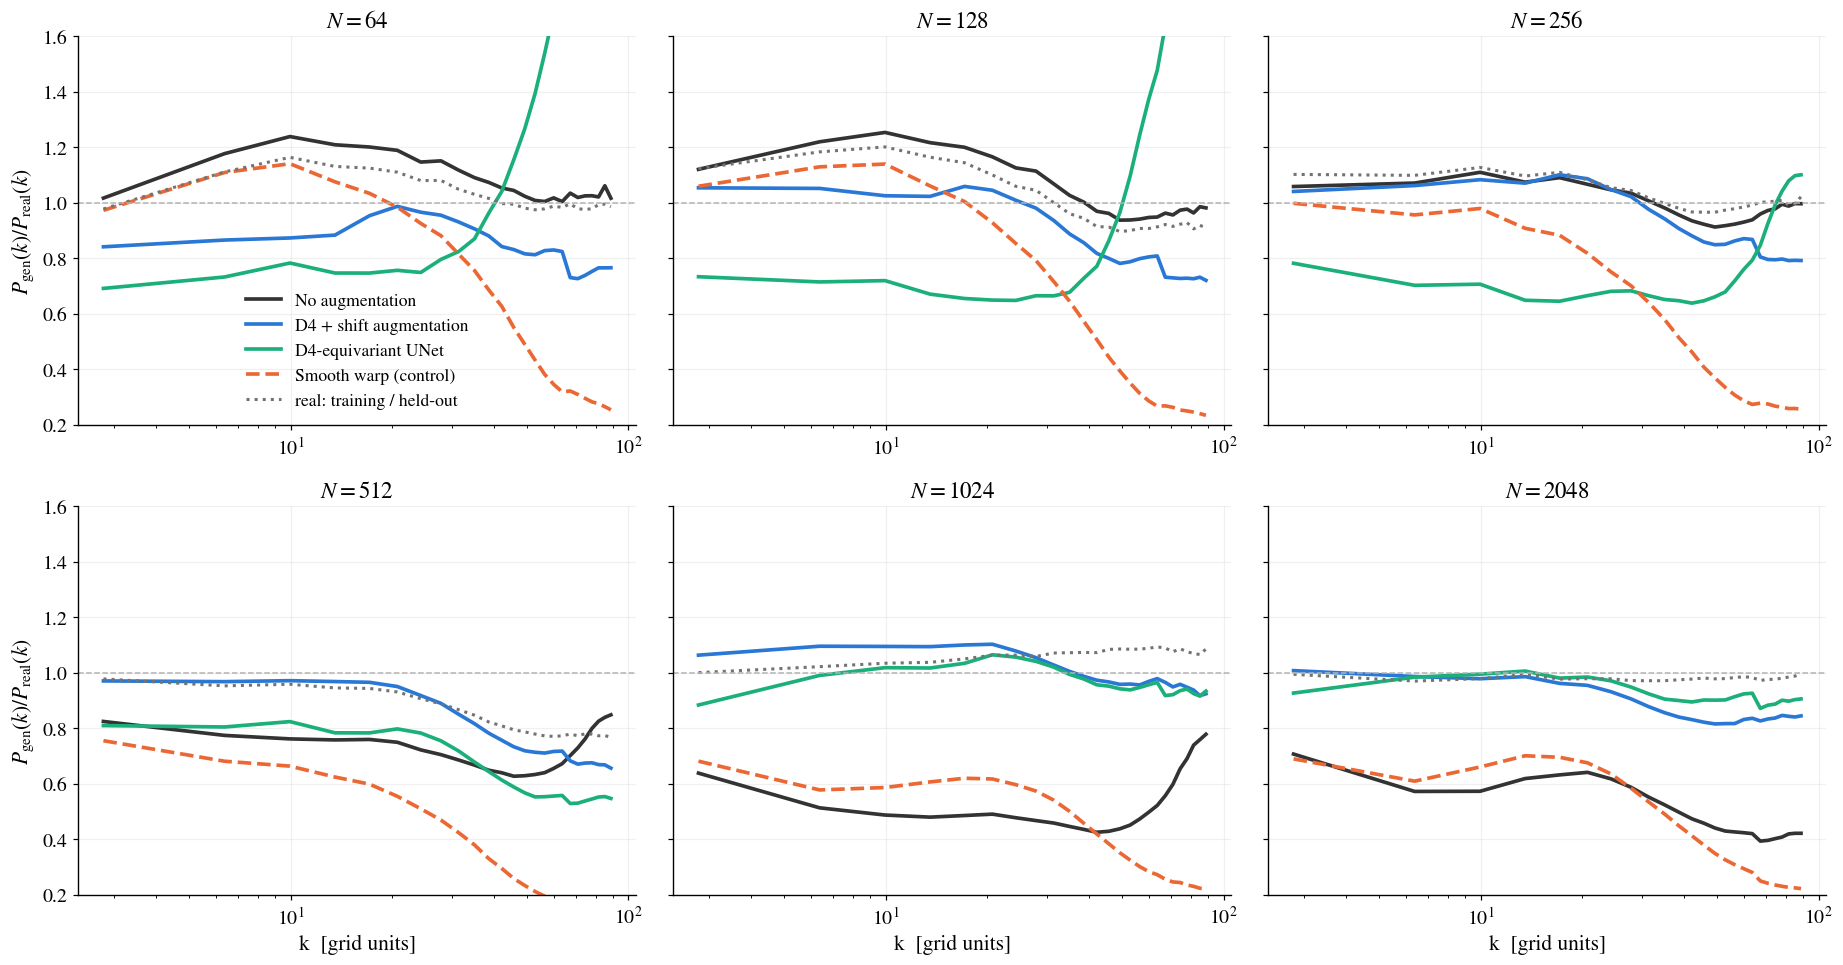

In [4]:
kc = curves['kc']
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey=True)
for ax, n in zip(axes.ravel(), [64, 128, 256, 512, 1024, 2048]):
    for arm in ARMS:
        r = table[(table.dataset_size == n) & (table.arm == arm)]
        if len(r):
            ax.plot(kc, curves[f'{r.run_name.iloc[0]}__pk_ratio'], color=STYLE[arm]['color'],
                    ls=STYLE[arm].get('ls', '-'), label=NAME[arm])
    ax.plot(kc, curves[f'N{n}_reference__pk_ratio'], color='0.45', ls=':', lw=2, label='real: training / held-out')
    ax.axhline(1, color='0.7', lw=1, ls='--')
    ax.set(xscale='log', title=f'$N = {n}$', ylim=(0.2, 1.6))
    ax.grid(alpha=0.18)
for ax in axes[1]: ax.set_xlabel('k  [grid units]')
for ax in axes[:, 0]: ax.set_ylabel('$P_\\mathrm{gen}(k) / P_\\mathrm{real}(k)$')
axes[0, 0].legend(frameon=False, fontsize=11.5)
plt.tight_layout(); plt.show()

## 3b. One-point statistics

The pixel-value distribution (one-point PDF) of generated maps, in the model's normalized units.
Gray fill: held-out real maps. Black dotted: training maps. A good model sits on the gray fill; a model that copies sits on the dotted line.

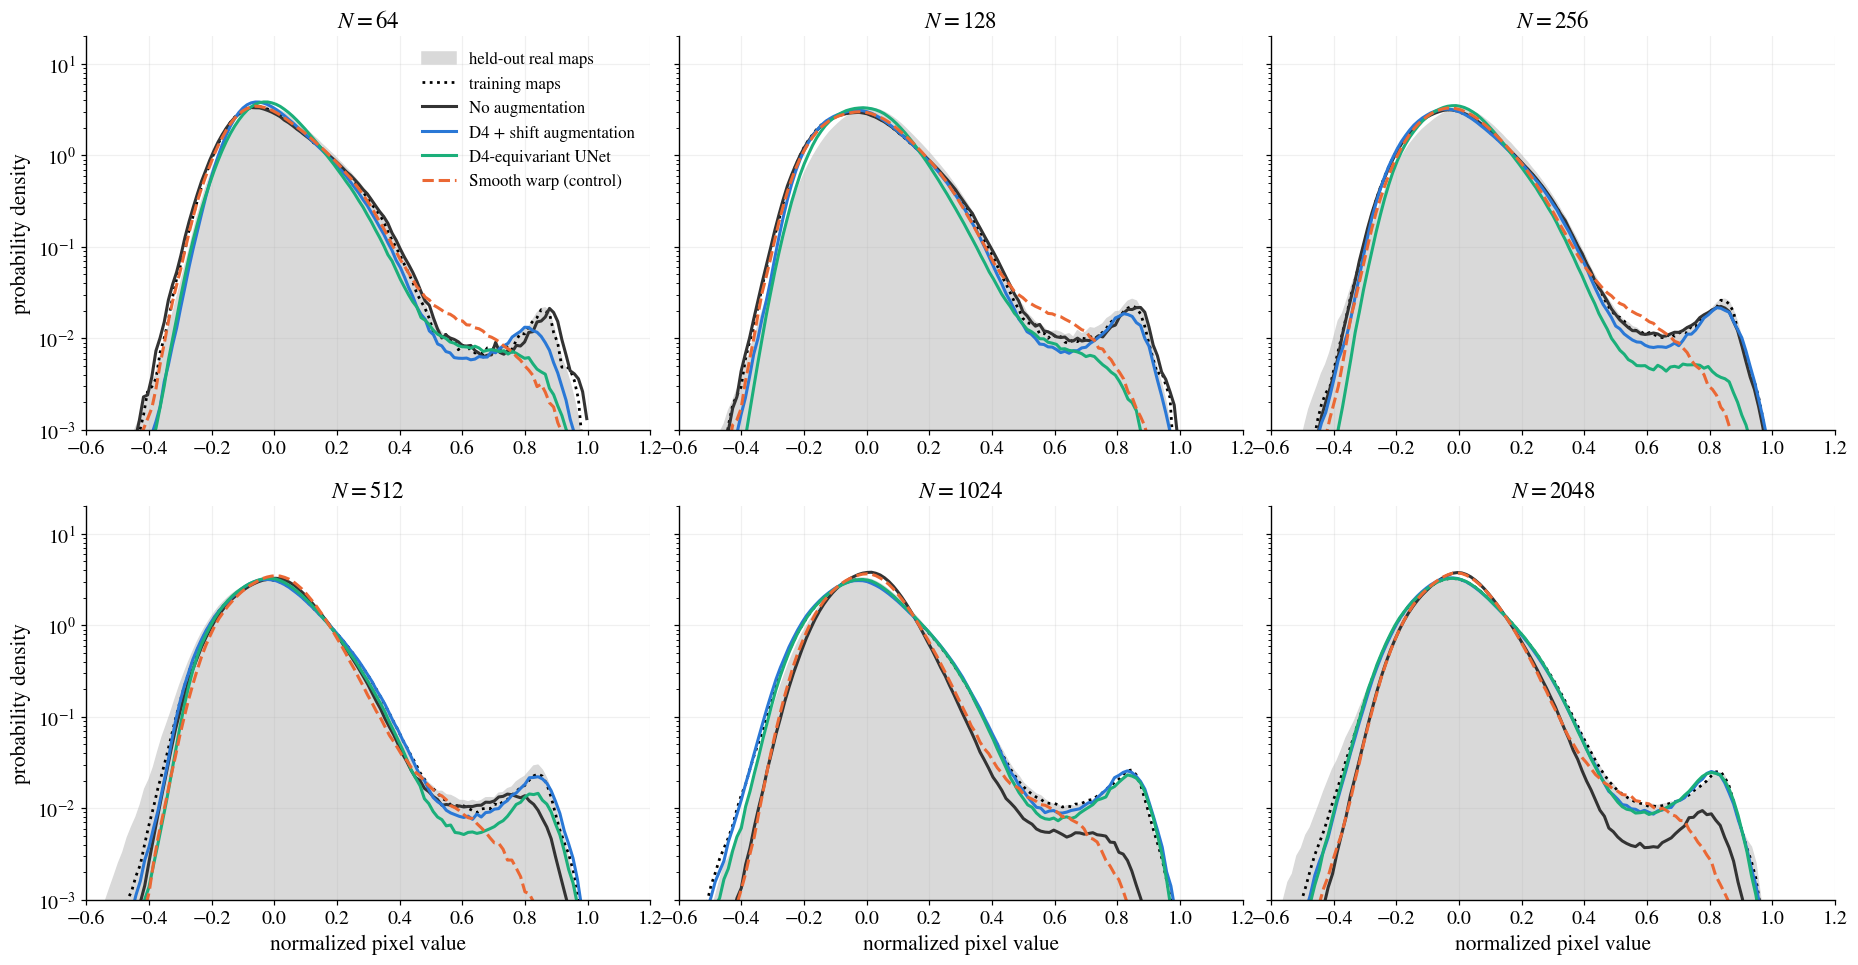

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey=True)
for ax, n in zip(axes.ravel(), [64, 128, 256, 512, 1024, 2048]):
    edges = curves[f'N{n}_reference__pdf_edges']; mid = 0.5 * (edges[1:] + edges[:-1])
    ax.fill_between(mid, curves[f'N{n}_reference__pdf_val'], color='0.85', label='held-out real maps')
    ax.plot(mid, curves[f'N{n}_reference__pdf_train'], color='k', ls=':', lw=1.8, label='training maps')
    for arm in ARMS:
        r = table[(table.dataset_size == n) & (table.arm == arm)]
        ax.plot(mid, curves[f'{r.run_name.iloc[0]}__pdf_gen'], color=STYLE[arm]['color'], ls=STYLE[arm].get('ls', '-'),
                lw=2, label=NAME[arm])
    ax.set(yscale='log', ylim=(1e-3, 20), xlim=(-0.6, 1.2), title=f'$N = {n}$')
    ax.grid(alpha=0.18)
for ax in axes[1]: ax.set_xlabel('normalized pixel value')
for ax in axes[:, 0]: ax.set_ylabel('probability density')
axes[0, 0].legend(frameon=False, fontsize=11)
plt.tight_layout(); plt.show()

**Moments of the one-point PDF vs N.** Gray dotted: held-out real maps (the target). Pixel mean, spread, skewness, tail weight
(excess kurtosis) and the 99th percentile (bright filaments/halos).

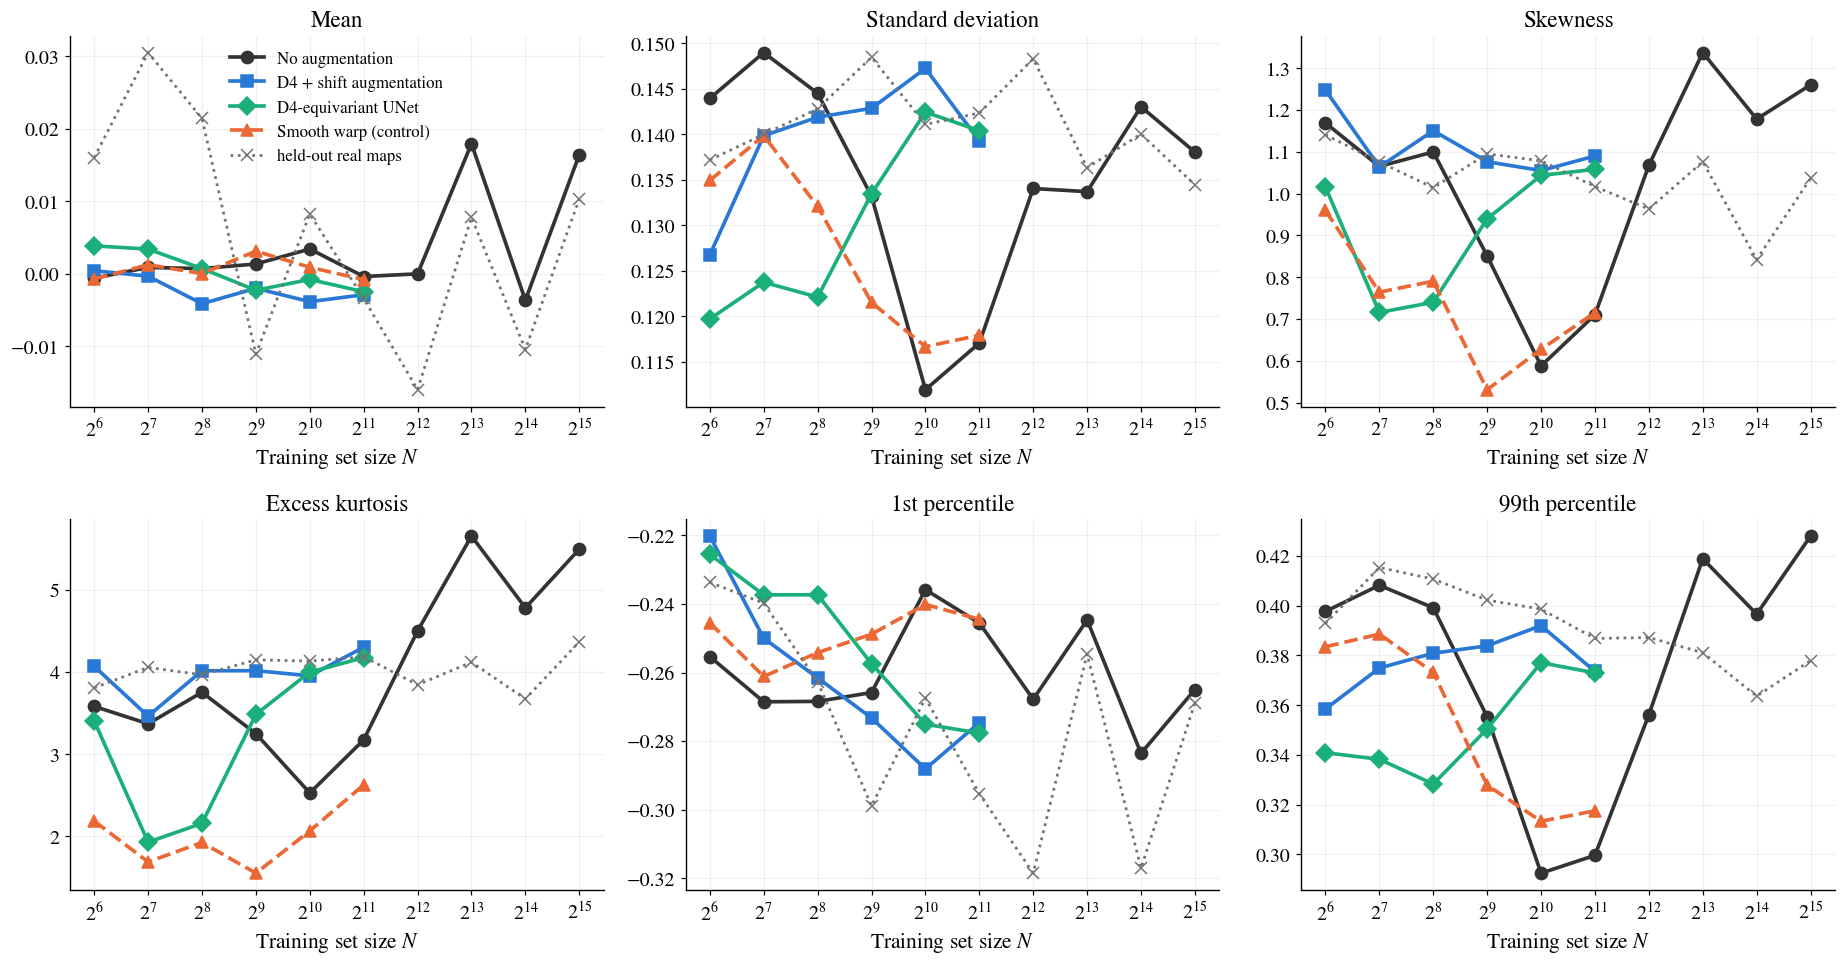

std  real std   skew  real skew  excess_kurtosis  \
dataset_size arm                                                           
64           noaug    0.144     0.137  1.169      1.141            3.581   
             d4shift  0.127     0.137  1.248      1.141            4.068   
             d4equiv  0.120     0.137  1.016      1.141            3.404   
             warp     0.135     0.137  0.960      1.141            2.188   
128          noaug    0.149     0.140  1.065      1.076            3.369   
             d4shift  0.140     0.140  1.064      1.076            3.462   
             d4equiv  0.124     0.140  0.716      1.076            1.930   
             warp     0.140     0.140  0.764      1.076            1.690   
256          noaug    0.145     0.143  1.100      1.014            3.752   
             d4shift  0.142     0.143  1.151      1.014            4.013   
             d4equiv  0.122     0.143  0.740      1.014            2.159   
             warp     0.132     0.143  0.791      1.014            1.927   
512          noaug    0.133     0.148  0.851      1.095            3.249   
             d4shift  0.143     0.148  1.076      1.095            4.015   
             d4equiv  0.133     0.148  0.940      1.095            3.483   
             warp     0.122     0.148  0.531      1.095            1.553   
1024         noaug    0.112     0.141  0.588      1.079            2.528   
             d4shift  0.147     0.141  1.055      1.079            3.952   
             d4equiv  0.142     0.141  1.044      1.079            3.997   
             warp     0.117     0.141  0.628      1.079            2.066   
2048         noaug    0.117     0.142  0.710      1.017            3.173   
             d4shift  0.139     0.142  1.090      1.017            4.300   
             d4equiv  0.140     0.142  1.058      1.017            4.173   
             warp     0.118     0.142  0.715      1.017            2.628   
4096         noaug    0.134     0.148  1.068      0.963            4.498   
8192         noaug    0.134     0.136  1.337      1.077            5.651   
16384        noaug    0.143     0.140  1.178      0.842            4.779   
32768        noaug    0.138     0.134  1.260      1.037            5.492   

                      real excess_kurtosis    q99  real q99  one_point_l1  \
dataset_size arm                                                            
64           noaug                   3.806  0.398     0.393         0.152   
             d4shift                 3.806  0.358     0.393         0.141   
             d4equiv                 3.806  0.341     0.393         0.115   
             warp                    3.806  0.383     0.393         0.131   
128          noaug                   4.055  0.408     0.415         0.231   
             d4shift                 4.055  0.375     0.415         0.224   
             d4equiv                 4.055  0.338     0.415         0.160   
             warp                    4.055  0.389     0.415         0.206   
256          noaug                   3.965  0.399     0.411         0.165   
             d4shift                 3.965  0.381     0.411         0.204   
             d4equiv                 3.965  0.328     0.411         0.156   
             warp                    3.965  0.373     0.411         0.158   
512          noaug                   4.147  0.355     0.402         0.139   
             d4shift                 4.147  0.384     0.402         0.066   
             d4equiv                 4.147  0.350     0.402         0.095   
             warp                    4.147  0.328     0.402         0.203   
1024         noaug                   4.131  0.292     0.399         0.171   
             d4shift                 4.131  0.392     0.399         0.095   
             d4equiv                 4.131  0.377     0.399         0.064   
             warp                    4.131  0.313     0.399         0.128   
2048         noaug                   4.185  0.300

In [6]:
mom = [('mean', 'Mean'), ('std', 'Standard deviation'), ('skew', 'Skewness'), ('excess_kurtosis', 'Excess kurtosis'),
       ('q01', '1st percentile'), ('q99', '99th percentile')]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
refs = table.drop_duplicates('dataset_size').sort_values('dataset_size')
for ax, (key, title) in zip(axes.ravel(), mom):
    for arm in ARMS:
        r = arm_rows(arm)
        ax.plot(r.dataset_size, r[f'gen_{key}'], label=NAME[arm], **STYLE[arm])
    ax.plot(refs.dataset_size, refs[f'ref_heldout_{key}'], **{**REF, 'label': 'held-out real maps'})
    ax.set_title(title); log2_axis(ax, sizes)
axes[0, 0].legend(frameon=False, fontsize=11)
plt.tight_layout(); plt.show()
cols = ['gen_std', 'ref_heldout_std', 'gen_skew', 'ref_heldout_skew', 'gen_excess_kurtosis', 'ref_heldout_excess_kurtosis',
        'gen_q99', 'ref_heldout_q99', 'one_point_l1', 'ref_one_point_l1']
t = table.set_index(['dataset_size', 'arm'])[cols]
t = t.reindex(sorted(t.index, key=lambda i: (i[0], ARMS.index(i[1]))))
display(t.round(3).rename(columns=lambda c: c.replace('ref_heldout_', 'real ').replace('gen_', '').replace('ref_', 'real ')))

**How to read it** (numbers from `per_run.csv`).

* **D4 + shift (blue):** the PDF sits on the real maps from N = 2⁷ on (pixel std 0.140–0.147 vs real 0.140–0.148). At N = 2⁶ it is
  slightly too narrow (std 0.127 vs 0.137) and its brightest pixels are a little dim at every N (99th percentile 0.358–0.392 vs real
  0.387–0.415), consistent with its missing small-scale power.
* **D4-equivariant UNet (green):** too narrow up to N = 2⁹ (std 0.120–0.133) with a weak bright tail (99th percentile 0.328–0.350).
* **Smooth warp (orange):** loses the bright tail from N = 2⁹ (99th percentile 0.313–0.328).
* **No augmentation (black):** copies the training PDF at small N; at its transition (N = 2¹⁰–2¹¹) the bright tail collapses
  (std 0.112/0.117 vs real 0.141/0.142; 99th percentile 0.292/0.300 vs 0.399/0.387).

## 3c. Training loss: are the models trained long enough?

From `results/unet128_aug_sweep/loss_curves_20261008_181725/` (2000-update running mean). For no augmentation at N ≤ 1024 the
per-update records were overwritten by a later continuation, so those curves are rebuilt from the per-epoch average loss printed in
the original training logs (checked against the per-update record at N = 2048: last-20k mean agrees to 0.006%).
**Absolute loss is not comparable across arms** (augmented and equivariant runs fit a different target). What matters is whether each
curve is still falling at 200k updates.

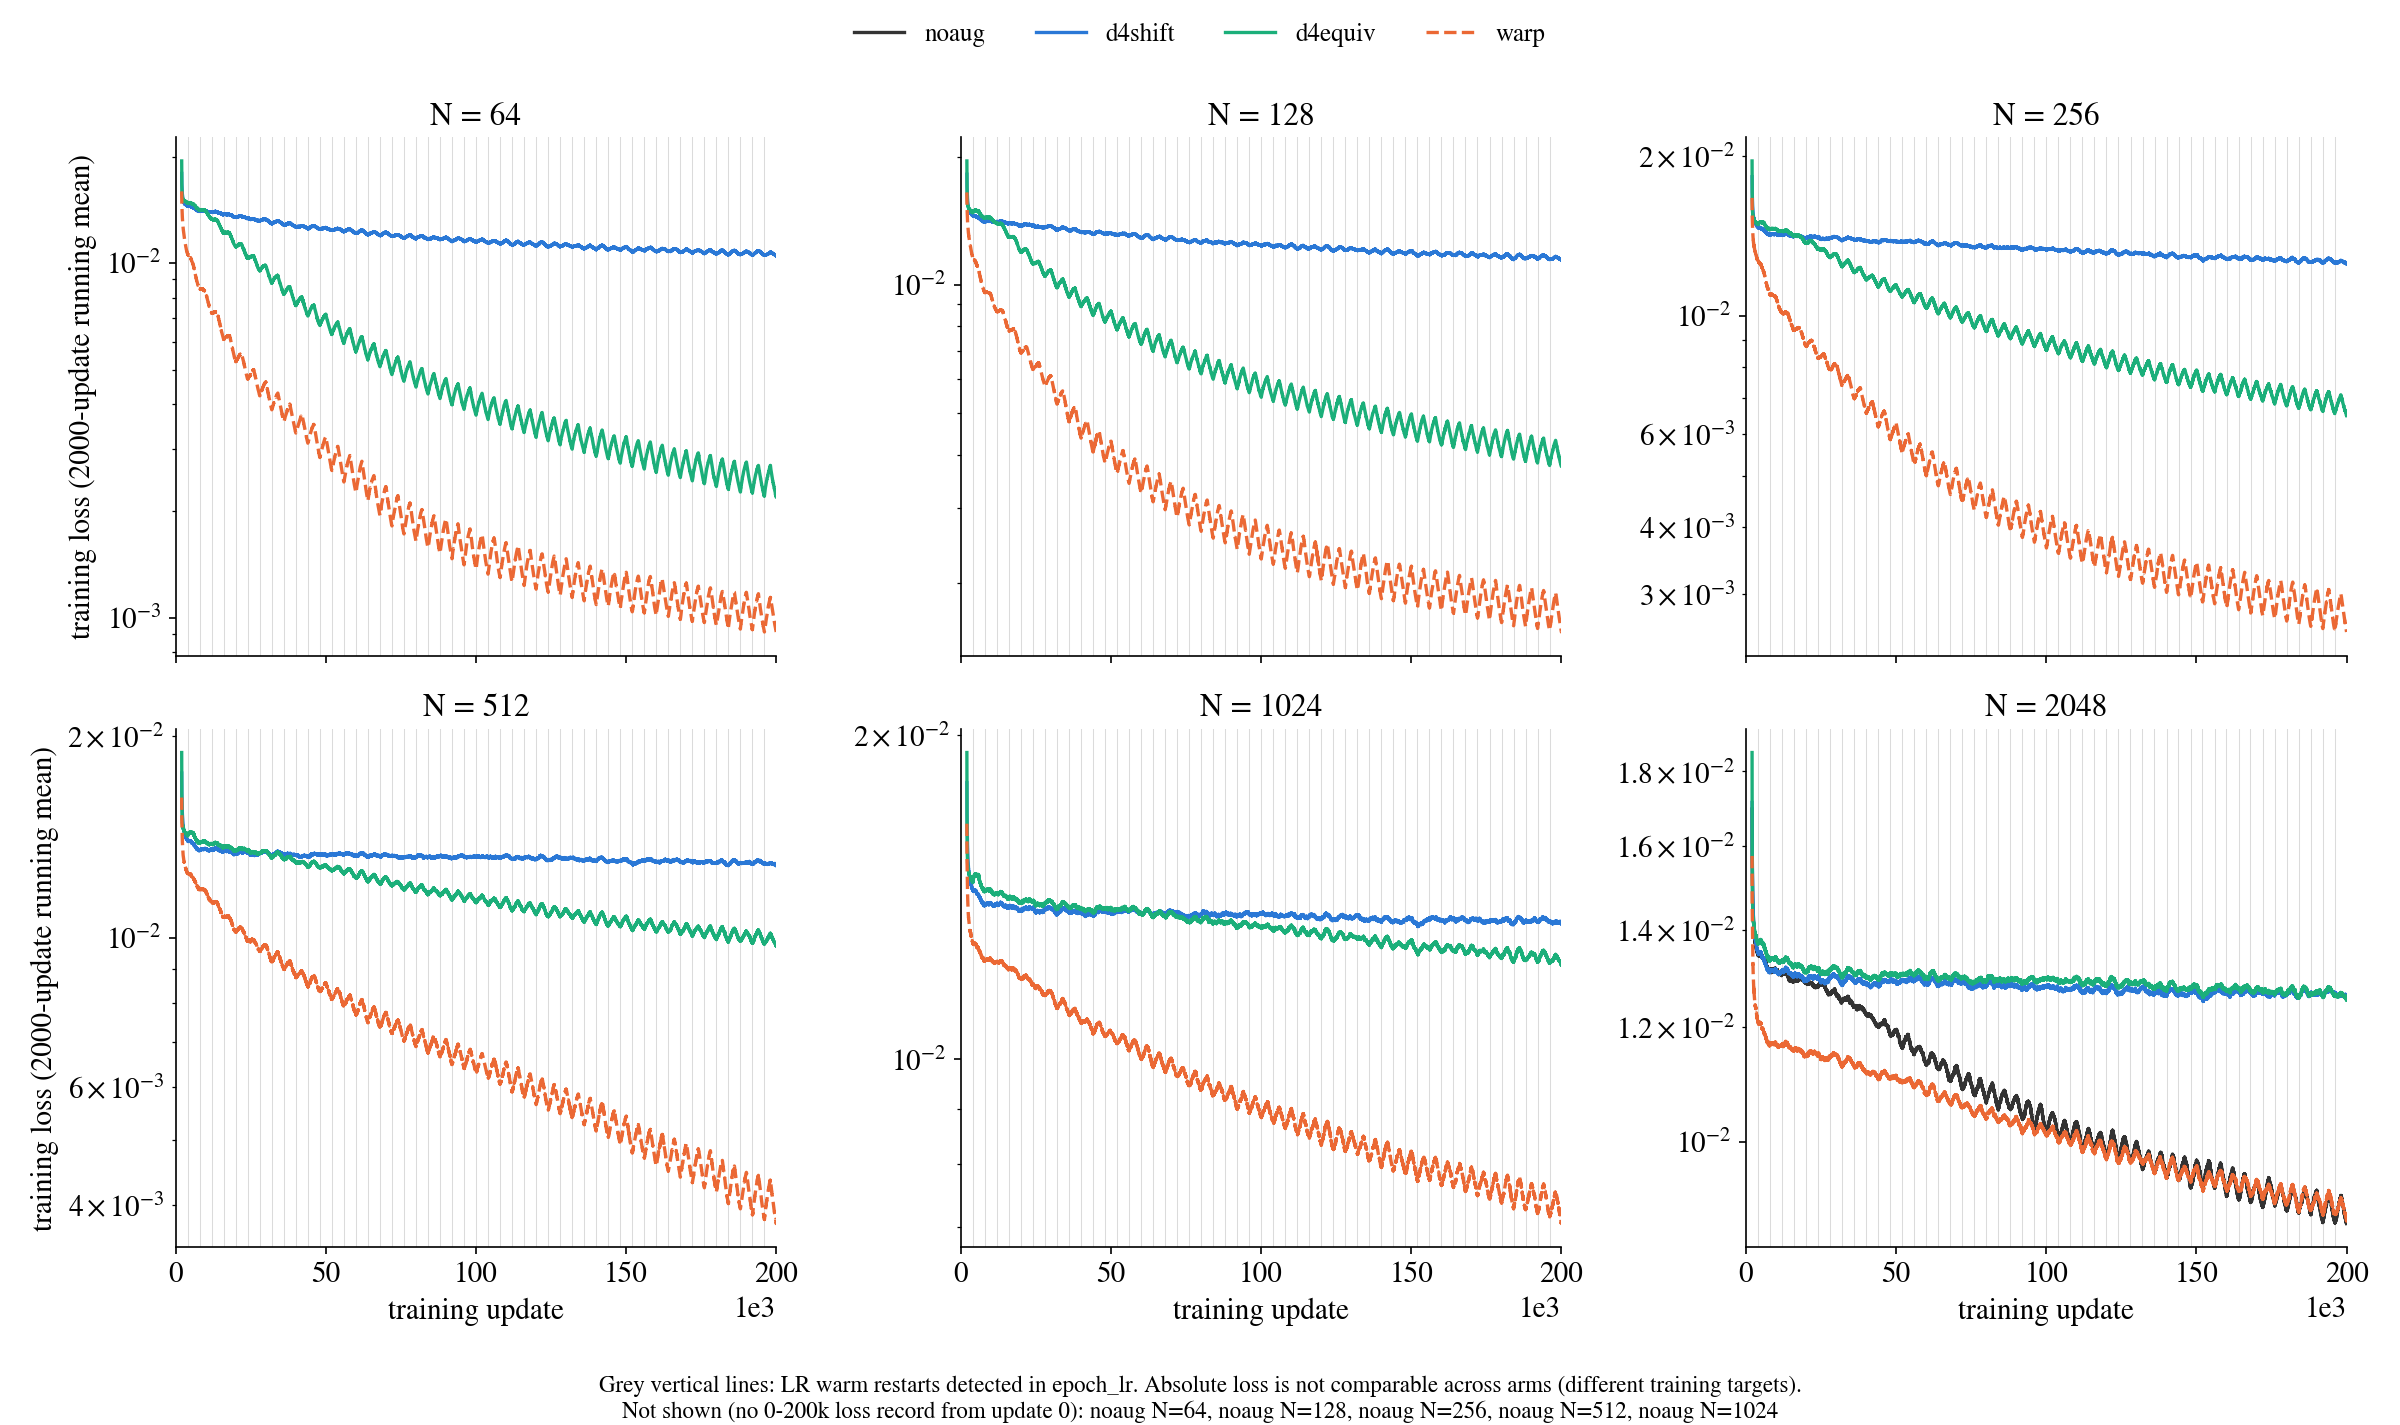

arm,noaug,d4shift,d4equiv,warp
N,,,,
64,NaN,-1.33,-7.77,-6.00
128,NaN,-1.18,-5.63,-5.81
256,NaN,-0.91,-4.19,-5.25
512,NaN,-0.44,-2.31,-9.68
1024,NaN,-0.14,-1.21,-3.54
2048,-2.19,-0.06,-0.44,-2.09
4096,-1.47,NaN,NaN,NaN
8192,-0.62,NaN,NaN,NaN
16384,-0.00,NaN,NaN,NaN


In [7]:
from IPython.display import Image
LOSS = PROJECT_DIR / 'results/unet128_aug_sweep/loss_curves_20261008_181725'
display(Image(filename=str(LOSS / 'loss_curves.png'), width=1150))
conv = pd.read_csv(LOSS / 'convergence.csv')
conv = conv[conv.status == 'ok'][['arm', 'N', 'mean_loss_160k_180k', 'mean_loss_180k_200k', 'rel_change_last_vs_prev']]
conv['change in last 20k updates (%)'] = 100 * conv.pop('rel_change_last_vs_prev')
display(conv.pivot(index='N', columns='arm', values='change in last 20k updates (%)')[[a for a in ARMS if a in set(conv.arm)]].round(2))

**How to read it** (change of the mean loss from updates 160–180k to 180–200k, `convergence.csv`).

* **No augmentation:** still falling at small N (−8.6% at N = 64, −3.0% at 1024, −1.5% at 4096); flat from N = 16384. At small N a
  falling loss means fitting the copies ever more tightly, not learning to generalize.
* **D4 + shift:** nearly flat (−1.3% at N = 64 down to −0.06% at N = 2048), levelling off near the loss the no-augmentation model reaches
  when it generalizes (N ≥ 2¹³: about 0.0124–0.0126).
* **D4-equivariant UNet** (−7.8% at N = 64) and **warp** (−2% to −10%) are still clearly improving: not converged.

A flat loss does not prove the *samples* have converged; the checkpoint sweep (job 63559649) scores samples from every 20k updates.

## 4. Copy test, map by map

Each generated map's similarity to its closest training map, allowing rotation, flip and shift. Dashed: copy threshold.
Gray: held-out real maps scored the same way, i.e. what a genuinely new map looks like.

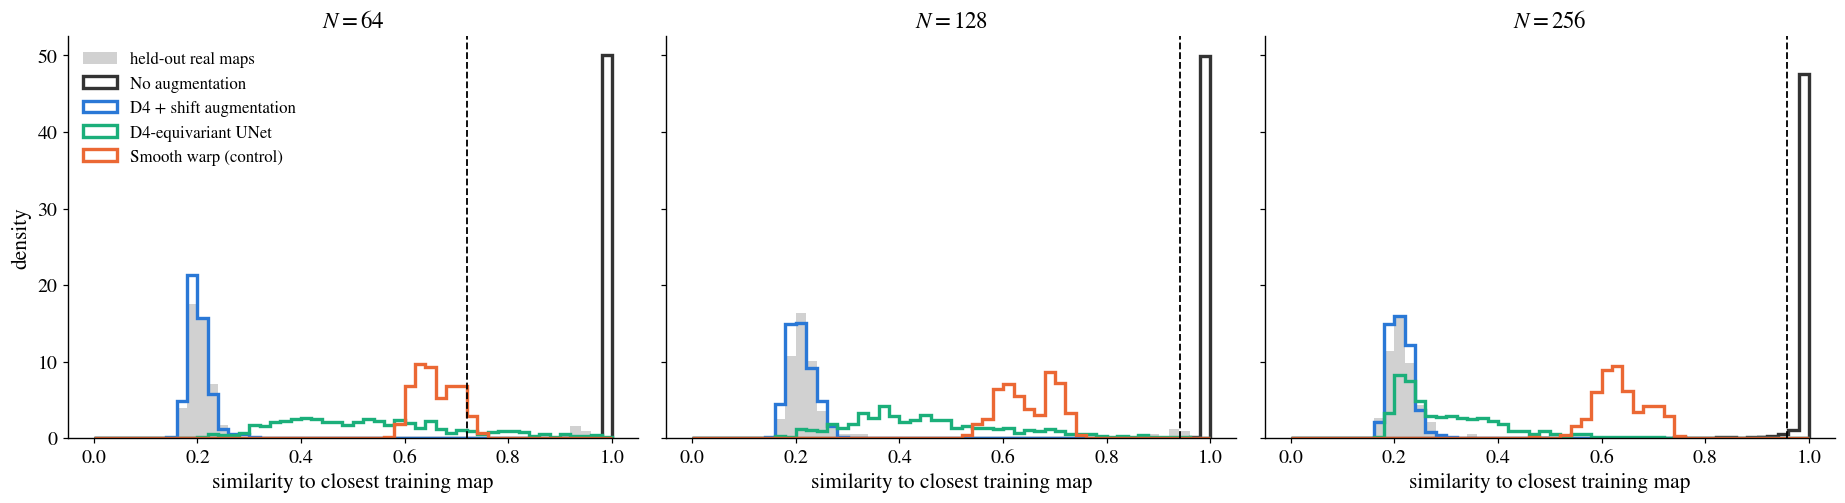

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
bins = np.linspace(0, 1, 51)
for ax, n in zip(axes, (64, 128, 256)):
    for arm in ARMS:
        r = table[(table.dataset_size == n) & (table.arm == arm)]
        z = np.load(RES / f'{r.run_name.iloc[0]}_per_sample.npz')
        if arm == 'noaug':
            ax.hist(z['heldout_orbit_nn'], bins=bins, color='0.82', density=True, label='held-out real maps')
        ax.hist(z['orbit_nn'], bins=bins, histtype='step', lw=2.2, color=STYLE[arm]['color'], density=True, label=NAME[arm])
    ax.axvline(float(r.orbit_threshold.iloc[0]), color='k', ls='--', lw=1.2)
    ax.set(title=f'$N = {n}$', xlabel='similarity to closest training map')
axes[0].set_ylabel('density'); axes[0].legend(frameon=False, fontsize=11)
plt.tight_layout(); plt.show()

## 5. What the maps look like

Top row: four training maps from four different simulations. Below: the first four saved samples of each arm. Same color scale.

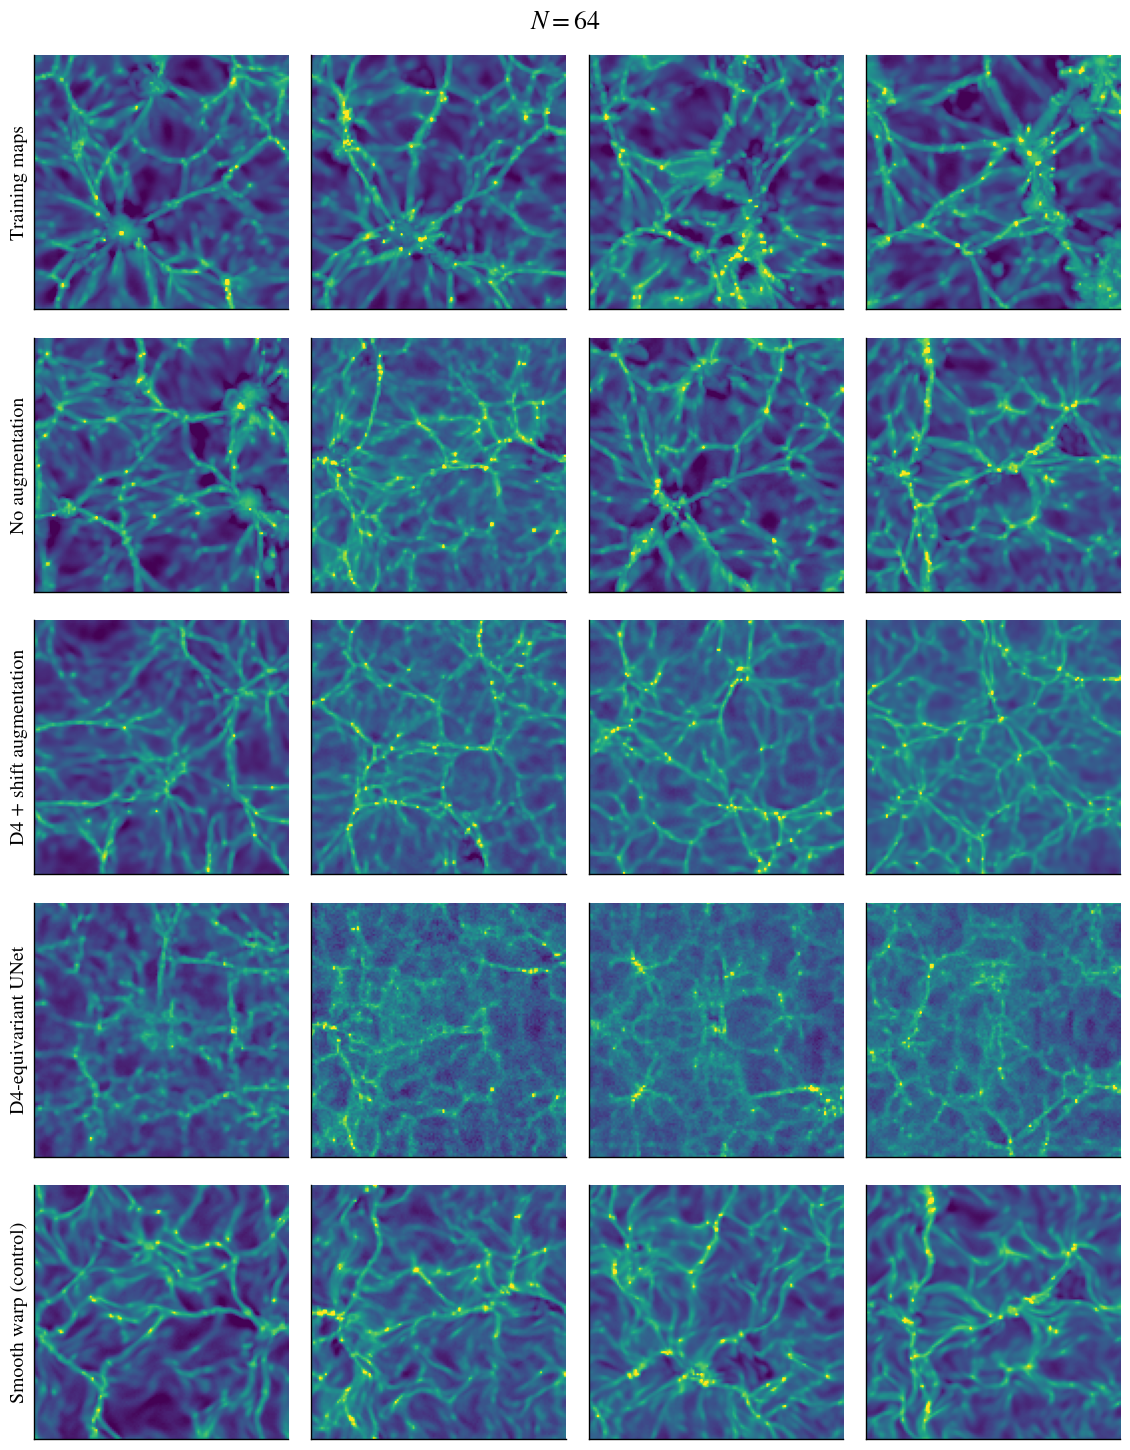

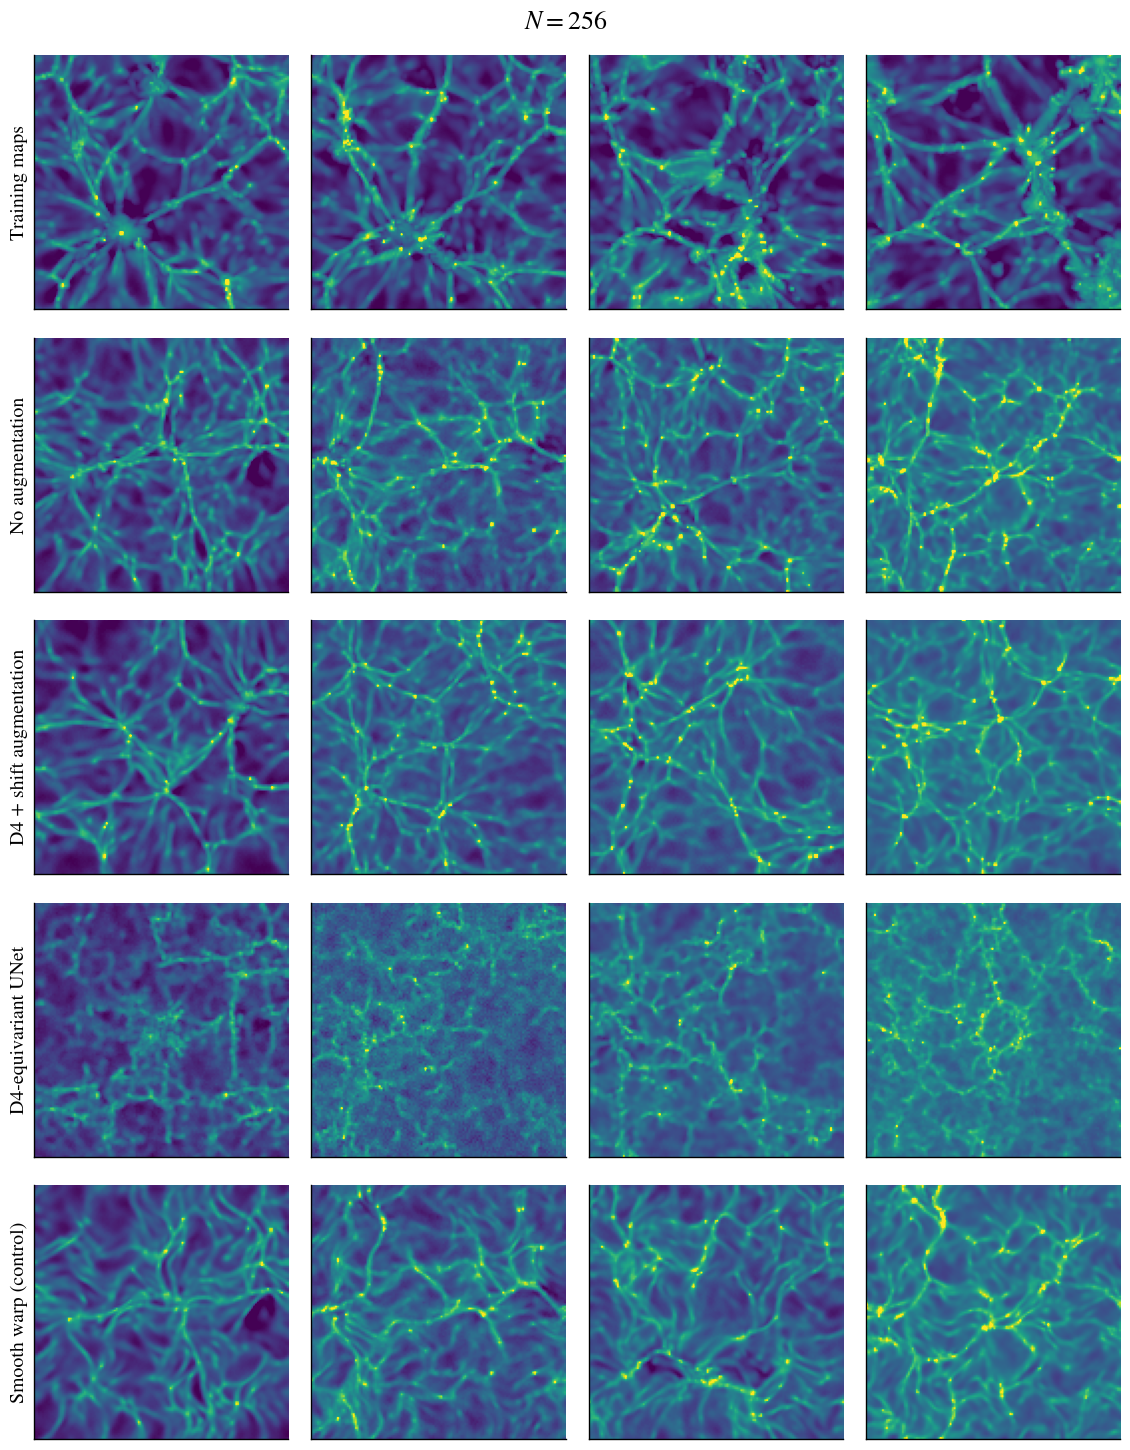

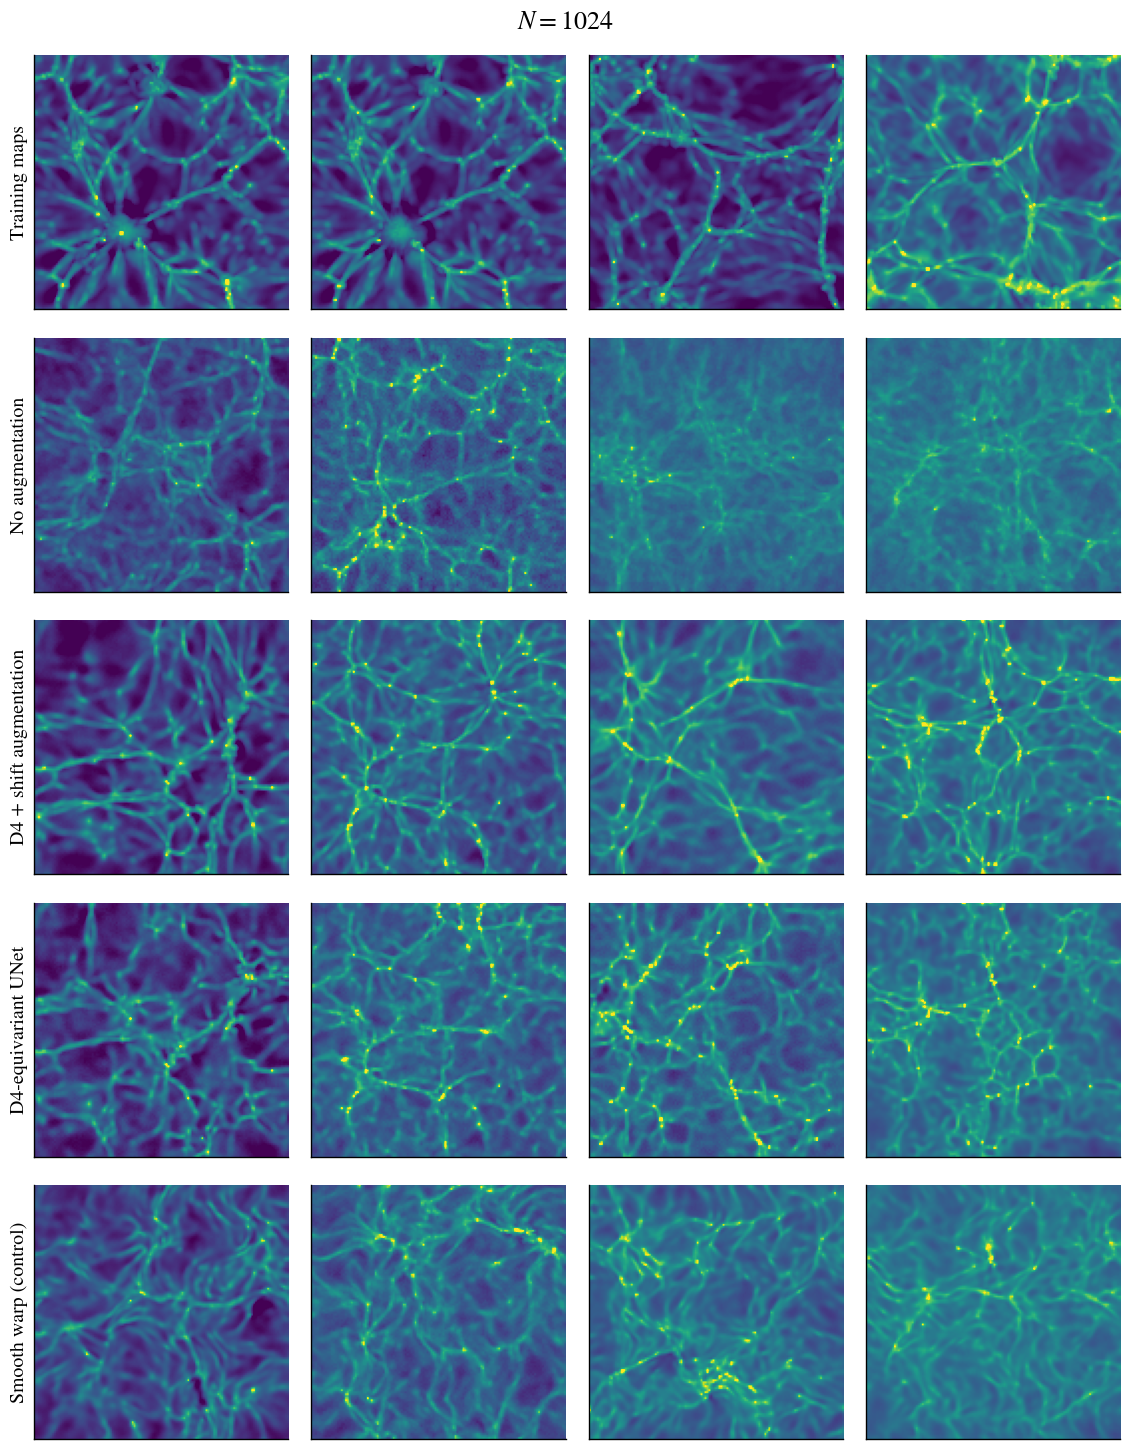

In [9]:
from simdiff_eval.io import iter_real_reference_batches_from_config
for n in (64, 256, 1024):
    sub = table[table.dataset_size == n]
    first = next(iter_real_reference_batches_from_config(PROJECT_DIR / sub.config.iloc[0]))[:, 0]
    train = first[::16][:4] if len(first) >= 64 else first[:4]
    fig, axes = plt.subplots(5, 4, figsize=(10.5, 13.5))
    rows = [('Training maps', train)]
    for arm in ARMS:
        with np.load(PROJECT_DIR / sub[sub.arm == arm].sample_path.iloc[0]) as z:
            rows.append((NAME[arm], z['samples'][:4, 0]))
    for i, (label, maps) in enumerate(rows):
        for j in range(4):
            axes[i, j].imshow(maps[j], cmap='viridis', vmin=-0.3, vmax=0.6)
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        axes[i, 0].set_ylabel(label, fontsize=13)
    fig.suptitle(f'$N = {n}$', fontsize=17); plt.tight_layout(); plt.show()

## 6. Caveats

* One training seed per cell; the no-augmentation baseline was trained without an explicit seed.
* D4 + shift turns each map into 8 × 128² variants, so "not copying" partly reflects a much larger effective training set; the quality panels, not G, show whether the new maps are right.
* N = 64 is only **2 simulation boxes** (LH and CV simulation 0) at z = 0 and z = 1, not 4 independent simulations.
* The copy threshold is set by training-to-training similarity, which is low at N = 64 (0.72, slices of the same box) and 0.94–0.97 for
  N ≥ 128; so the copy test is least strict exactly where the headline result sits. 6% of held-out real maps exceed it at N = 64.
* The no-augmentation crossing rests on one single-seed point (G = 0.45 at N = 512); a second seed there would test it.
* The VGG regressor was trained on LH z = 0 maps; on these maps (LH + CV, z = 0, 1, 2) it is only a fixed summary statistic, not cosmology inference.
* A recovery/coverage figure (Ωm recovered vs requested) needs **conditional** models with augmentation; these unconditional runs cannot give one.